In [71]:
import requests 
import pandas as pd 
import numpy as np
import json
import time 
import os 
from pathlib import Path

In [116]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.float_format","{:.2f}".format)

In [92]:
os.makedirs("data/raw", exist_ok=True)
COUNTRIES = [
    "KEN", "TZA", "UGA", "ETH", "RWA",       # East Africa
    "NGA", "GHA", "CIV", "SEN",               # West Africa
    "EGY", "MAR", "TUN",                      # North Africa
    "ZAF", "BWA", "ZMB",                      # Southern Africa
    "USA", "GBR", "DEU", "FRA", "JPN",        # Major advanced
    "CHN", "IND", "BRA", "MEX", "IDN",        # Large EM (IDN not TUR twice)
    "TUR", "THA", "MYS", "PHL", "VNM",        # Asia EM
    "SAU", "ARE", "NOR", "AUS", "CAN",        # Commodity exporters ← comma here
    "POL", "CZE", "HUN", "ROU",               # Eastern Europe
    "ARG", "CHL", "COL", "PER",               # Latin America
    "KOR", "SGP", "PAK", "BGD",              # Other Asia ← comma here
    "ISL", "NZL", "CRI",                      # Small open economies
]
INDICATORS= {
    "NY.GDP.MKTP.KD.ZG": "gdp_growth",
    "FP.CPI.TOTL.ZG": "inflation",
    "SL.UEM.TOTL.ZS": "unemployment",
    "FR.INR.LEND": "lending_rate",
    "NE.TRD.GNFS.ZS": "trade_opennes",
    "BN.CAB.XOKA.GD.ZS": "govt_debt",
    "NY.GDP.PCAP.KD.ZG": "gdp_per_capita_growth"
}

START_YEAR= 1995
END_YEAR=2023
# RAW_PATH = Path(r"data/raw/wb_raw.csv")
# PROCESSED_PATH=Path(r"data/processed/panel.csv")
# TENSOR_PATH= Path(r"data/processed/tensor.npy")
# META_PATH = Path(r"data/processed/metadata.json")

In [93]:
def fetch_indicator(code, name, countries ,start_year,end_year):
    country_str=";".join(countries)
    url=(
        f"https://api.worldbank.org/v2/country/{country_str}/indicator/{code}?date={start_year}:{end_year}&format=json&per_page=10000"
    )
    resp=requests.get(url,timeout=30)
    resp.raise_for_status()
    payload=resp.json()
        
    if not isinstance(payload,list):
        print(f"Unexpected response for {code}: {payload}")
        return pd.DataFrame()
    if len(payload) < 2 or not payload[1]:
        print(f"Unexpected response for {code}: {payload}")
        print(f" Raw response: {payload[0]}")
        return pd.DataFrame()

    records=[
        {
            "country_iso3":item["countryiso3code"],
            "country_name": item["country"]["value"],
            "year": int(item["date"]),
            name: item["value"]
        }
        for item in payload[1]
    ]
    return pd.DataFrame(records)

panel=None

for code,name in INDICATORS.items():
    print(f"Fetching: {name}...")
    df= fetch_indicator(code,name,COUNTRIES,START_YEAR,END_YEAR)
    panel= df if panel is None else panel.merge(
        df[["country_iso3","year",name]],
        on=["country_iso3","year"],
        how="outer"

    )
    time.sleep(0.5)

panel = panel.sort_values(["country_iso3","year"]).reset_index(drop=True)

panel.to_csv("data/raw/wb_panel_raw.csv", index=False)

print(f"\nShape: {panel.shape}")
print(f"Countries: {panel['country_iso3'].nunique()}")
print(f"Years: {panel["year"].min()} - {panel['year'].max()}")

print("\n --- Missing Value Per Column-----")
for col in list(INDICATORS.values()):
    n= panel[col].isna().sum()
    pct= panel[col].isna().mean() * 100
    print(f" {col:<28} {n:>5} missing ({pct:.1f}%)")

print("\n--- Kenya rows(all years)--------")
print(panel[panel["country_iso3"]=="KEN"].to_string(index=False))
print("\nSaved")


Fetching: gdp_growth...
Fetching: inflation...
Fetching: unemployment...
Fetching: lending_rate...
Fetching: trade_opennes...
Fetching: govt_debt...
Fetching: gdp_per_capita_growth...

Shape: (1450, 10)
Countries: 50
Years: 1995 - 2023

 --- Missing Value Per Column-----
 gdp_growth                       0 missing (0.0%)
 inflation                       38 missing (2.6%)
 unemployment                     0 missing (0.0%)
 lending_rate                   421 missing (29.0%)
 trade_opennes                   51 missing (3.5%)
 govt_debt                       62 missing (4.3%)
 gdp_per_capita_growth            0 missing (0.0%)

--- Kenya rows(all years)--------
country_iso3 country_name  year  gdp_growth  inflation  unemployment  lending_rate  trade_opennes  govt_debt  gdp_per_capita_growth
         KEN        Kenya  1995    4.406217   1.554328         2.848     28.795833      71.745742 -17.446216               1.483737
         KEN        Kenya  1996    4.146839   8.864087         2.773   

In [94]:
missing_by_country=(
    panel.groupby("country_iso3")[["lending_rate","trade_opennes", "govt_debt", "inflation"]]
    .apply(lambda g: g.isna().mean() *100).round(1)
)
print(missing_by_country[missing_by_country["lending_rate"]> 0]. sort_values("lending_rate",ascending=False))

              lending_rate  trade_opennes  govt_debt  inflation
country_iso3                                                   
ARE                  100.0           20.7       96.6       44.8
FRA                  100.0            0.0        0.0        0.0
TUN                  100.0            0.0        0.0        0.0
DEU                  100.0            0.0        0.0        0.0
MAR                  100.0            0.0        0.0        0.0
GHA                  100.0            0.0        0.0        0.0
SAU                  100.0            0.0        0.0        0.0
TUR                  100.0            0.0        0.0        0.0
POL                  100.0            0.0        0.0        0.0
NOR                   62.1            0.0        0.0        0.0
SEN                   58.6            0.0        0.0        0.0
CIV                   58.6            0.0       34.5        0.0
ARG                   51.7            0.0        0.0       79.3
ETH                   51.7           55.

In [95]:
missing_by_country = (
    panel.groupby("country_iso3")[list(INDICATORS.values())]
    .apply(lambda g: g.isna().sum())
)

In [96]:
panel= panel.drop(columns=["lending_rate"])

In [97]:
panel.columns

Index(['country_iso3', 'country_name', 'year', 'gdp_growth', 'inflation',
       'unemployment', 'trade_opennes', 'govt_debt', 'gdp_per_capita_growth'],
      dtype='str')

In [98]:
panel.isna().sum()

country_iso3              0
country_name              0
year                      0
gdp_growth                0
inflation                38
unemployment              0
trade_opennes            51
govt_debt                62
gdp_per_capita_growth     0
dtype: int64

In [99]:
panel["country_name"].unique()

<StringArray>
['United Arab Emirates',            'Argentina',            'Australia',
           'Bangladesh',               'Brazil',             'Botswana',
               'Canada',                'Chile',                'China',
        'Cote d'Ivoire',             'Colombia',           'Costa Rica',
              'Czechia',              'Germany',     'Egypt, Arab Rep.',
             'Ethiopia',               'France',       'United Kingdom',
                'Ghana',              'Hungary',            'Indonesia',
                'India',              'Iceland',                'Japan',
                'Kenya',          'Korea, Rep.',              'Morocco',
               'Mexico',             'Malaysia',              'Nigeria',
               'Norway',          'New Zealand',             'Pakistan',
                 'Peru',          'Philippines',               'Poland',
              'Romania',               'Rwanda',         'Saudi Arabia',
              'Senegal',            '

In [100]:
panel.isna().groupby(panel["country_name"]).sum()

,country_iso3,country_name,year,gdp_growth,inflation,unemployment,trade_opennes,govt_debt,gdp_per_capita_growth
country_name,,,,,,,,,
Argentina,0,0,0,0,23,0,0,0,0
Australia,0,0,0,0,0,0,0,0,0
Bangladesh,0,0,0,0,0,0,0,0,0
Botswana,0,0,0,0,0,0,0,0,0
Brazil,0,0,0,0,0,0,0,0,0
Canada,0,0,0,0,0,0,0,0,0
Chile,0,0,0,0,0,0,0,0,0
China,0,0,0,0,0,0,0,0,0
Colombia,0,0,0,0,0,0,0,0,0


In [101]:
panel1=panel.copy()
panel1[panel1["country_name"]=="Rwanda"]

,country_iso3,country_name,year,gdp_growth,inflation,unemployment,trade_opennes,govt_debt,gdp_per_capita_growth
1073,RWA,Rwanda,1995,35.224078,NaN,11.938,30.972173,NaN,61.873535
1074,RWA,Rwanda,1996,12.745696,7.411372,11.507,32.230066,NaN,-4.642289
1075,RWA,Rwanda,1997,13.849752,12.015423,11.087,33.467461,NaN,-1.512872
1076,RWA,Rwanda,1998,8.858669,6.210067,11.255,28.794464,NaN,4.461546
1077,RWA,Rwanda,1999,4.351888,-2.405932,11.569,27.333536,NaN,3.503655
1078,RWA,Rwanda,2000,8.370896,3.899530,11.699,27.484864,NaN,7.499871
1079,RWA,Rwanda,2001,8.484560,3.342855,11.732,29.198909,NaN,7.526799
1080,RWA,Rwanda,2002,13.192074,1.992585,11.432,27.609438,NaN,11.668245
1081,RWA,Rwanda,2003,2.202388,7.449700,11.658,29.310624,NaN,-0.019687
1082,RWA,Rwanda,2004,7.447667,12.250710,11.699,33.461673,NaN,4.645119


In [102]:
DROP = [
    "ARG",  # missing 2023 inflation + hyperinflation distortion
    "ARE",  # 28 govt debt, 13 inflation, 6 trade openness
    "NGA",  # 29 trade openness — structural reporting problem
    "ETH",  # 16 trade openness
    "CIV",  # 10 govt debt
    "RWA",  # only starts 2009 — too short
]
panel=panel[~panel["country_iso3"].isin(DROP)].reset_index(drop=True)

print(f"Shape: {panel.shape}")

Shape: (1276, 9)


In [103]:
panel

,country_iso3,country_name,year,gdp_growth,inflation,unemployment,trade_opennes,govt_debt,gdp_per_capita_growth
0,AUS,Australia,1995,3.890172,4.627764,8.473,37.646874,-5.063186,2.739531
1,AUS,Australia,1996,3.865675,2.615379,8.509,38.174021,-3.583603,2.612517
2,AUS,Australia,1997,3.917958,0.224895,8.367,37.921701,-2.729749,2.799586
3,AUS,Australia,1998,4.676814,0.860130,7.684,39.924066,-4.441118,3.638646
4,AUS,Australia,1999,5.028220,1.483139,6.876,38.960247,-5.583664,3.885499
...,...,...,...,...,...,...,...,...,...
1271,ZMB,Zambia,2019,1.441306,9.150316,5.538,68.791205,0.603691,-1.518950
1272,ZMB,Zambia,2020,-2.785055,15.733060,6.032,79.206849,11.790957,-5.567735
1273,ZMB,Zambia,2021,6.234922,22.020768,5.197,86.208511,11.900351,3.285755
1274,ZMB,Zambia,2022,5.211224,10.993204,5.993,69.297315,3.747847,2.343365


#### PRE-PROCESSING

In [104]:
panel.isna().sum()

country_iso3             0
country_name             0
year                     0
gdp_growth               0
inflation                1
unemployment             0
trade_opennes            0
govt_debt                9
gdp_per_capita_growth    0
dtype: int64

In [105]:
panel.isna().groupby(panel["country_name"]).sum()

,country_iso3,country_name,year,gdp_growth,inflation,unemployment,trade_opennes,govt_debt,gdp_per_capita_growth
country_name,,,,,,,,,
Australia,0,0,0,0,0,0,0,0,0
Bangladesh,0,0,0,0,0,0,0,0,0
Botswana,0,0,0,0,0,0,0,0,0
Brazil,0,0,0,0,0,0,0,0,0
Canada,0,0,0,0,0,0,0,0,0
Chile,0,0,0,0,0,0,0,0,0
China,0,0,0,0,0,0,0,0,0
Colombia,0,0,0,0,0,0,0,0,0
Costa Rica,0,0,0,0,0,0,0,0,0


In [109]:
panel.describe()

,year,gdp_growth,inflation,unemployment,trade_opennes,govt_debt,gdp_per_capita_growth
count,1276.000000,1276.000000,1275.000000,1276.000000,1276.000000,1267.000000,1276.000000
mean,2009.000000,3.791526,6.262637,6.765469,72.720599,-0.708571,2.445158
std,8.369881,3.315354,9.772913,4.917186,54.862746,6.265530,3.264982
min,1995.000000,-14.144235,-2.248021,0.249000,15.635591,-22.953427,-15.899715
25%,2002.000000,2.137697,1.961520,3.495750,43.100443,-4.129926,0.953368
50%,2009.000000,3.919390,3.754944,5.297000,59.515777,-1.801723,2.501779
75%,2016.000000,5.789513,7.179664,8.475250,80.771684,1.516204,4.353164
max,2023.000000,14.519750,154.763480,34.007000,437.326715,28.847434,14.430816


In [112]:
import matplotlib.pyplot as plt

feature_cols=[c for c in panel.columns if c not in ["country_iso3","country_name","year"]]
print(panel[feature_cols].describe().round(2).to_string())

       gdp_growth  inflation  unemployment  trade_opennes  govt_debt  gdp_per_capita_growth
count     1276.00    1275.00       1276.00        1276.00    1267.00                1276.00
mean         3.79       6.26          6.77          72.72      -0.71                   2.45
std          3.32       9.77          4.92          54.86       6.27                   3.26
min        -14.14      -2.25          0.25          15.64     -22.95                 -15.90
25%          2.14       1.96          3.50          43.10      -4.13                   0.95
50%          3.92       3.75          5.30          59.52      -1.80                   2.50
75%          5.79       7.18          8.48          80.77       1.52                   4.35
max         14.52     154.76         34.01         437.33      28.85                  14.43


In [117]:
for col in feature_cols:
    Q1= panel[col].quantile(0.25)
    Q3=panel[col].quantile(0.75)
    IQR=Q3-Q1

    outliers=panel[
        (panel[col]<Q1-3 *IQR) |
        (panel[col]> Q3 + 3*IQR)

    ][["country_iso3","year", col]].sort_values(col,ascending=False)

    if not outliers.empty:
        print(f"\n {col} OUTLIERS")
        print(outliers.to_string(index=False))


 gdp_growth OUTLIERS
country_iso3  year  gdp_growth
         TUN  2020       -8.98
         PHL  2020       -9.52
         GBR  2020      -10.05
         PER  2020      -10.93
         IDN  1998      -13.13
         BWA  2009      -14.14

 inflation OUTLIERS
country_iso3  year  inflation
         ROU  1997     154.76
         TUR  1995      89.11
         TUR  1997      85.67
         TUR  1998      84.64
         TUR  1996      80.41
         TUR  2022      72.31
         BRA  1995      66.01
         TUR  1999      64.87
         GHA  1995      59.46
         ROU  1998      59.10
         IDN  1998      58.45
         TUR  2000      54.92
         TUR  2001      54.40
         TUR  2023      53.86
         GHA  1996      46.56
         ROU  1999      45.80
         ROU  2000      45.67
         TUR  2002      44.96
         ZMB  1996      43.07
         GHA  2001      41.51
         GHA  2000      40.24
         ROU  1996      38.83
         GHA  2023      38.11
         MEX  1995  

C:\Users\Admin\AppData\Local\Temp\ipykernel_22004\1924963520.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(panel[col].dropna(),vert=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_22004\1924963520.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(panel[col].dropna(),vert=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_22004\1924963520.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(panel[col].dropna(),vert=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_22004\1924963520.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orient

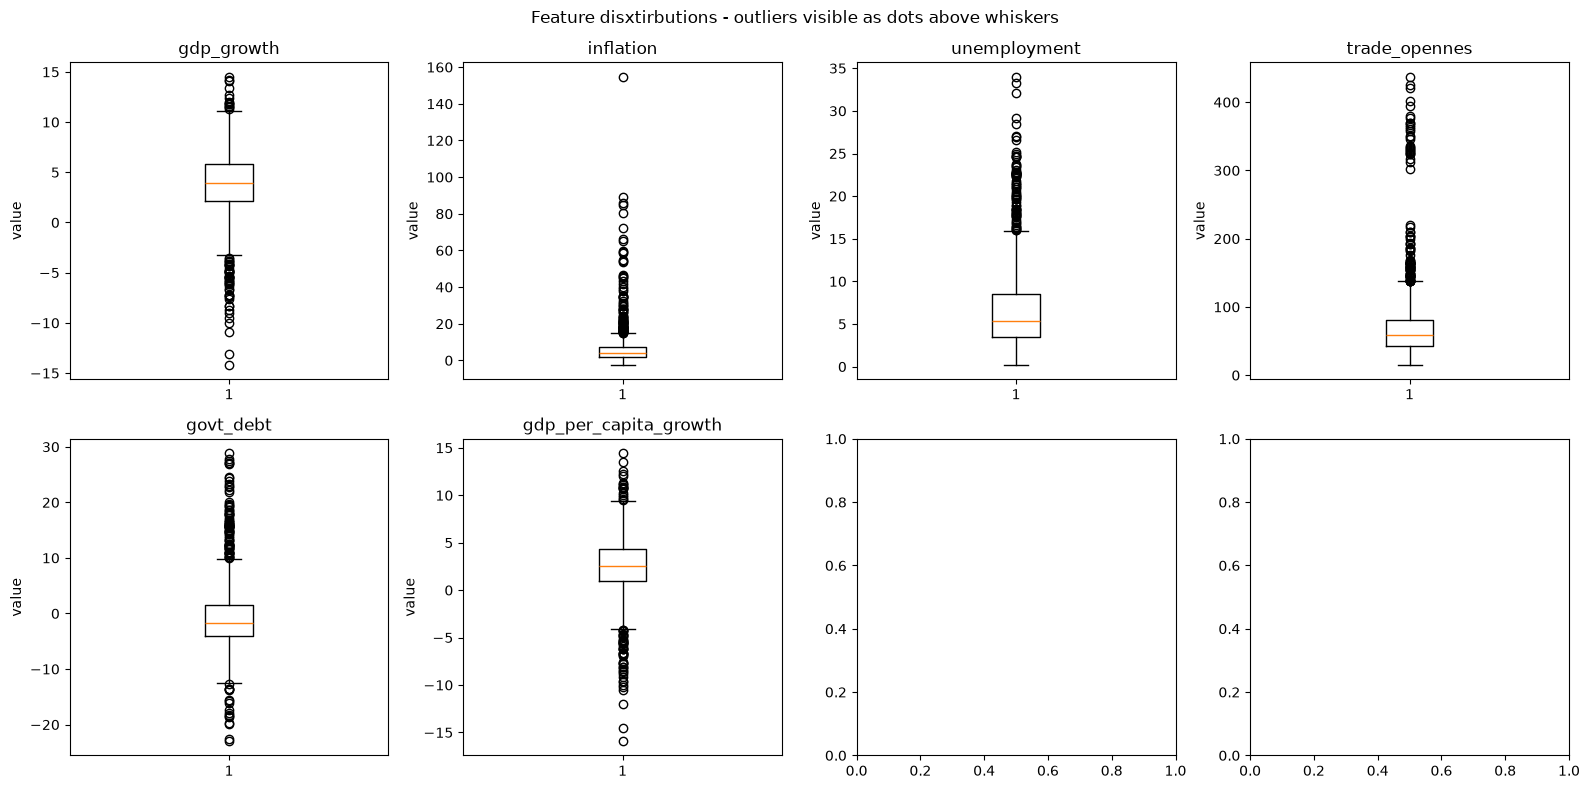

In [114]:
fig, axes  =plt.subplots(2,4,figsize=(16,8))
axes=axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].boxplot(panel[col].dropna(),vert=True)
    axes[i].set_title(col)
    axes[i].set_ylabel("value")

plt.suptitle("Feature disxtirbutions - outliers visible as dots above whiskers")
plt.tight_layout()
plt.show()

In [125]:
Q3=panel["inflation"].quantile(0.01)
Q3

np.float64(-0.9064229198407645)

In [ ]:
for col in feature_cols:
    lo=panel[col].quantile(0.01)
    hi=panel[col].quantile(0.99)
    panel[col]=panel[col].clip(lo,hi)


In [132]:
for country,group in panel.groupby('country_iso3'):
    idx=group.index
    panel.loc[idx, feature_cols]=(
        group[feature_cols].interpolate(method="linear",
                                        limit=2,limit_direction="both")
    )

print("missing_data_after_interpolation:")
print(panel[feature_cols].isna().sum())

missing_data_after_interpolation:
gdp_growth               0
inflation                0
unemployment             0
trade_opennes            0
govt_debt                3
gdp_per_capita_growth    0
dtype: int64


In [133]:
before=len(panel)
panel=panel.dropna(subset=feature_cols)
after= len(panel)


In [134]:
print(panel[panel["trade_opennes"]> 150][["country_iso3","year","trade_opennes"]].to_string(index=False))

country_iso3  year  trade_opennes
         CZE  2014         156.42
         CZE  2015         154.02
         HUN  2007         155.60
         HUN  2008         158.45
         HUN  2010         157.84
         HUN  2011         166.75
         HUN  2012         166.18
         HUN  2013         164.48
         HUN  2014         168.36
         HUN  2015         167.29
         HUN  2016         163.97
         HUN  2017         165.03
         HUN  2018         162.70
         HUN  2019         159.93
         HUN  2020         154.53
         HUN  2021         159.19
         HUN  2022         185.00
         HUN  2023         158.39
         MYS  1995         192.11
         MYS  1996         181.77
         MYS  1997         185.67
         MYS  1998         209.49
         MYS  1999         217.57
         MYS  2000         220.41
         MYS  2001         203.36
         MYS  2002         199.36
         MYS  2003         194.20
         MYS  2004         210.37
         MYS  

In [130]:
print(panel[feature_cols].describe().round(2).to_string())
print(panel[panel["inflation"] > 30][["country_iso3","year","inflation"]].to_string(index=False))

       gdp_growth  inflation  unemployment  trade_opennes  govt_debt  gdp_per_capita_growth
count     1276.00    1275.00       1276.00        1276.00    1267.00                1276.00
mean         3.80       6.05          6.73          72.40      -0.70                   2.45
std          3.19       7.92          4.77          52.83       6.00                   3.13
min         -7.18      -0.91          0.61          21.24     -13.67                  -8.20
25%          2.14       1.96          3.50          43.10      -4.13                   0.95
50%          3.92       3.75          5.30          59.52      -1.80                   2.50
75%          5.79       7.18          8.48          80.77       1.52                   4.35
max         11.35      54.00         24.58         351.86      21.94                  10.35
country_iso3  year  inflation
         BRA  1995      54.00
         EGY  2023      33.88
         GHA  1995      54.00
         GHA  1996      46.56
         GHA  2000    